In [74]:
# Importing necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [75]:
# Import data and clean it
df1 = pd.read_excel('fiscal_dashboard_data.xlsx')
exclude_cols = ['nepali_date','english_date','np_date','fiscal_year','day_of_year','name_of_the_day']
cols_to_clean = [c for c in df1.columns if c not in exclude_cols]
df1[cols_to_clean] = (df1[cols_to_clean].astype(str) .replace({',': '', ' ': '', '%': ''}, regex=True))
df1[cols_to_clean] = df1[cols_to_clean].apply(pd.to_numeric, errors='coerce')

In [76]:
# Select only three columns and the current fiscal year
df1 = df1[df1['fiscal_year'] == "2082_83"]
# df1 = df1[['day_of_year','total_revenue_percentage','total_expenditure_percentage']]
df1 = df1.iloc[4:].reset_index(drop=True)

In [77]:
# Forward fill with previous value if there is zero value
cols = ['total_revenue_percentage', 'total_expenditure_percentage']
df1[cols] = df1[cols].replace(0, np.nan)
df1[cols] = df1[cols].ffill()

In [79]:
df1.columns

Index(['nepali_date', 'english_date', 'np_date', 'fiscal_year', 'day_of_year',
       'name_of_the_day', 'total_revenue_target', 'tax_target',
       'non_tax_target', 'grant_target', 'other_receipts_target',
       'total_receipts_target', 'total_revenue_upto_yesterday',
       'tax_upto_yesterday', 'non_tax_upto_yesterday', 'grant_upto_yesterday',
       'other_receipts_upto_yesterday', 'total_receipts_upto_yesterday',
       'total_revenue_today', 'tax_today', 'non_tax_today', 'grant_today',
       'other_receipts_today', 'total_receipts_today',
       'total_revenue_upto_today', 'tax_upto_today', 'non_tax_upto_today',
       'grant_upto_today', 'other_receipts_upto_today',
       'total_receipts_upto_today', 'total_revenue_percentage',
       'tax_percentage', 'non_tax_percentage', 'grant_percentage',
       'other_receipts_percentage', 'total_receipts_percentage',
       'total_expenditure_target', 'recurrent_target', 'capital_target',
       'financing_target', 'total_expenditure

In [92]:
# Now make table
# Build base table
last = df1.iloc[-1]
summary_table = pd.DataFrame(
    {
        'target_amount': [last['total_revenue_target'],last['total_expenditure_target']],
        'Collection_to_Date': [last['total_revenue_upto_today'],last['total_expenditure_upto_today']],
        'Percentage': [last['total_revenue_percentage'],last['total_expenditure_percentage']]
    },
    index=['Revenue', 'Expenditure']
)

# Compute Surplus / Deficit (Revenue - Expenditure)
surplus_deficit = summary_table.loc['Revenue'] - summary_table.loc['Expenditure']
summary_table.loc['Surplus/Deficit'] = surplus_deficit
summary_table

,target_amount,Collection_to_Date,Percentage
Revenue,14800000.0,9042609.0,61.10
Expenditure,19641100.0,10832786.0,55.15
Surplus/Deficit,-4841100.0,-1790177.0,5.95


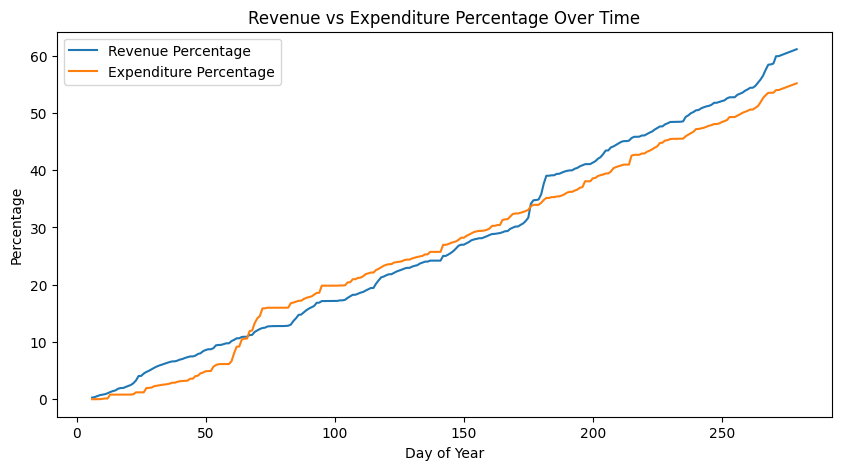

In [71]:
# Draw line plot
plt.figure(figsize=(10, 5))
plt.plot(df1['day_of_year'], df1['total_revenue_percentage'], label='Revenue Percentage')
plt.plot(df1['day_of_year'], df1['total_expenditure_percentage'], label='Expenditure Percentage')
plt.xlabel('Day of Year')
plt.ylabel('Percentage')
plt.title('Revenue vs Expenditure Percentage Over Time')
plt.legend()
plt.show()